   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520
Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

Multiple Linear Regression
MSE: 39933194.54805147
R2: 0.73981661775643

Ridge Regression
MSE: 39943138.4742946
R2: 0.7397518284403735

Lasso Regression
MSE: 39933175.7909889
R2: 0.7398167399674386


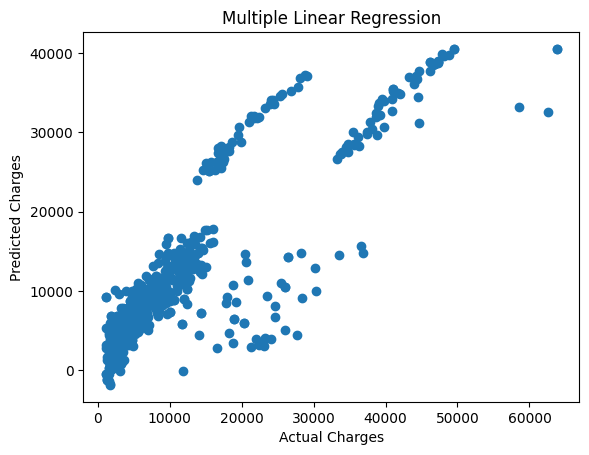

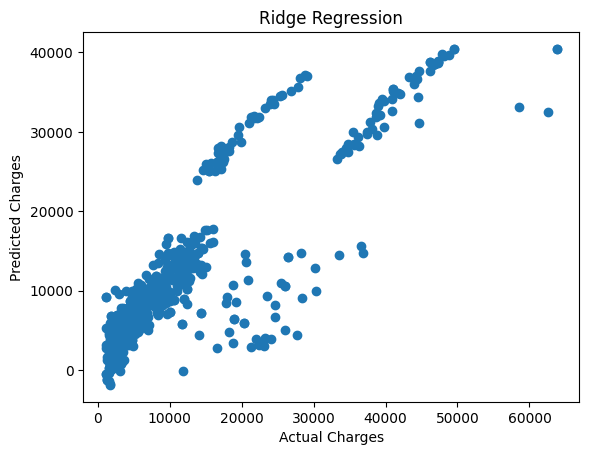

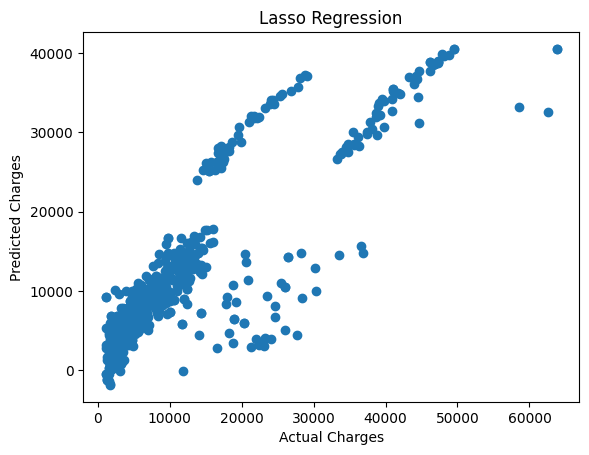

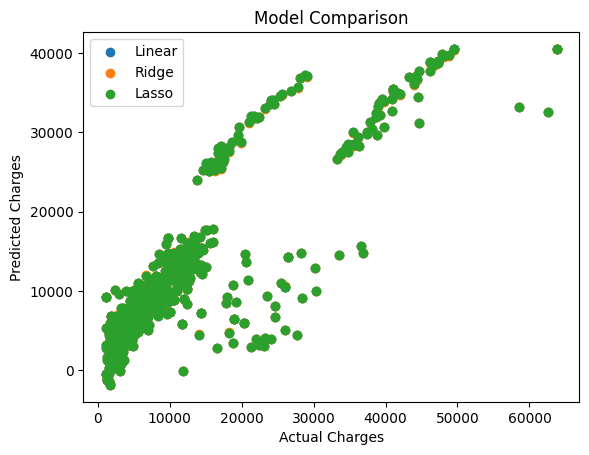

In [ ]:
# ===============================
# IMPORT LIBRARIES
# ===============================
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score


# ===============================
# LOAD DATASET
# ===============================
df = pd.read_csv("medical_insurance.csv")

print(df.head())
print(df.columns)


# ===============================
# ENCODE CATEGORICAL DATA
# ===============================
# sex, smoker, region are categorical
df = pd.get_dummies(df, drop_first=True)


# ===============================
# FEATURES & TARGET
# ===============================
X = df.drop("charges", axis=1)   # features
y = df["charges"]                # target


# ===============================
# TRAIN TEST SPLIT
# ===============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# ===============================
# MULTIPLE LINEAR REGRESSION
# ===============================
mlr = LinearRegression()
mlr.fit(X_train, y_train)
y_pred_mlr = mlr.predict(X_test)

print("\nMultiple Linear Regression")
print("MSE:", mean_squared_error(y_test, y_pred_mlr))
print("R2:", r2_score(y_test, y_pred_mlr))


# ===============================
# RIDGE REGRESSION
# ===============================
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)

print("\nRidge Regression")
print("MSE:", mean_squared_error(y_test, y_pred_ridge))
print("R2:", r2_score(y_test, y_pred_ridge))


# ===============================
# LASSO REGRESSION
# ===============================
lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)
y_pred_lasso = lasso.predict(X_test)

print("\nLasso Regression")
print("MSE:", mean_squared_error(y_test, y_pred_lasso))
print("R2:", r2_score(y_test, y_pred_lasso))


# ===============================
# VISUALIZATION
# ===============================

# Linear Regression
plt.scatter(y_test, y_pred_mlr)
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Multiple Linear Regression")
plt.show()

# Ridge Regression
plt.scatter(y_test, y_pred_ridge)
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Ridge Regression")
plt.show()

# Lasso Regression
plt.scatter(y_test, y_pred_lasso)
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Lasso Regression")
plt.show()

# Comparison Graph
plt.scatter(y_test, y_pred_mlr, label="Linear")
plt.scatter(y_test, y_pred_ridge, label="Ridge")
plt.scatter(y_test, y_pred_lasso, label="Lasso")

plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Model Comparison")
plt.legend()
plt.show()
